# Week 4: Feature Discovery for Query-Conditioned Evidence Allocation (QCCA)
**Project:** CS787 Generative AI — Query-Conditioned Context Allocator  
**Parent Framework:** SARA — Selective and Adaptive Retrieval-augmented Generation with Context Compression  
**Benchmark:** QASPER Development Split (86 papers, 231 queries)  
**Objective:** Answer the fundamental scientific question:  
> *What information available before generation correlates with how much textual evidence a query benefits from?*

---
### Investigation Framing
The initial Week 4 experiment tested six simple BM25 score-concentration features (`rho_1`, `delta_12`, `entropy`, etc.) and revealed weak associations with downstream evidence budgets.
Rather than forcing a complex predictive model, this study builds and evaluates a principled **64-feature library** spanning **6 distinct pre-generation information families**:
- **Family A: BM25 / Retrieval-Score Structure (17 features)**
- **Family B: Query Complexity (12 features)**
- **Family C: Query ↔ Retrieved-Passage Semantic Structure (11 features)**
- **Family D: Passage Redundancy / Diversity (10 features)**
- **Family E: Query / Passage Lexical Coverage (8 features)**
- **Family F: Evidence Structure / Multi-Aspect Signals (6 features)**

**CRITICAL EXPERIMENTAL BOUNDARIES:**
- **NO ML ALLOCATOR IS TRAINED OR FROZEN IN THIS NOTEBOOK.**
- **QASPER_test remains 100% UNTOUCHED and UNSEEN.**
- **All analysis is purely exploratory on the Development split.**

## 2. Frozen Experimental Setup & Configuration
Define paths, seeds, allocation action space $\mathcal{K}_{\text{alloc}} = \{2, 4, 5, 6, 8\}$, tolerance $\epsilon^* = 0.01$, and target directories.

In [1]:
import sys
import os
from pathlib import Path

# Ensure project root is on sys.path
PROJECT_ROOT = Path("..").resolve().parent if Path("..").resolve().name == "notebooks" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visual style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 1.0

# Experimental Constants
RANDOM_SEED = 42
N_BOOTSTRAP = 1000
N_CV_SPLITS = 5
EPSILON_STAR = 0.01
K_ALLOC = [2, 4, 5, 6, 8]

# Output Artifact Directory
OUT_DIR = PROJECT_ROOT / "results/week4/feature_discovery"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Output Artifacts: {OUT_DIR}")
print(f"Figures: {FIG_DIR}")
print(f"Action space K_alloc: {K_ALLOC}, epsilon*: {EPSILON_STAR}")

Project Root: /home/gunavenkat/Downloads/CS787-RAG-Project
Output Artifacts: /home/gunavenkat/Downloads/CS787-RAG-Project/results/week4/feature_discovery
Figures: /home/gunavenkat/Downloads/CS787-RAG-Project/results/week4/feature_discovery/figures
Action space K_alloc: [2, 4, 5, 6, 8], epsilon*: 0.01


## 3. Data & Artifact Verification
Verify presence of frozen Week-2 retrieval passages, response matrix, Week-3 epsilon targets, and cached SFR embeddings.

In [2]:
RAW_RETRIEVAL_PATH = PROJECT_ROOT / "results/week2/raw/dev_retrieval.jsonl"
DEV_MATRIX_PATH = PROJECT_ROOT / "results/week2/processed/dev_per_query_k_matrix.csv"
EPSILON_ORACLE_PATH = PROJECT_ROOT / "results/week3/processed/epsilon_oracle_all.csv"
PASSAGE_EMB_PATH = PROJECT_ROOT / "results/week2/raw/dev_sfr_embeddings.pt"
QUERY_EMB_PATH = PROJECT_ROOT / "results/week4/feature_discovery/dev_query_sfr_embeddings.pt"

for p, name in [
    (RAW_RETRIEVAL_PATH, "Raw retrieval records"),
    (DEV_MATRIX_PATH, "Dev per-query k-matrix"),
    (EPSILON_ORACLE_PATH, "Week-3 epsilon oracle targets"),
    (PASSAGE_EMB_PATH, "Cached passage SFR embeddings"),
    (QUERY_EMB_PATH, "Cached query SFR embeddings"),
]:
    assert p.exists(), f"Missing required artifact: {name} at {p}"
    print(f"[VERIFIED] {name} ({p.stat().st_size / 1024:.1f} KB)")

[VERIFIED] Raw retrieval records (2435.1 KB)
[VERIFIED] Dev per-query k-matrix (11.5 KB)
[VERIFIED] Week-3 epsilon oracle targets (43.7 KB)
[VERIFIED] Cached passage SFR embeddings (18659.9 KB)
[VERIFIED] Cached query SFR embeddings (3763.2 KB)


## 4. Leakage Policy & Automated Audit
Strict boundary check: verify that NO feature is derived from gold answers, gold evidence, generated answers, model logits, F1, EM, or oracle targets.

In [3]:
from src.week4.feature_discovery import audit_feature_leakage, get_feature_metadata

df_metadata = get_feature_metadata()
print(f"Total features specified in metadata: {len(df_metadata)}")
print("Feature distribution by family:")
display(df_metadata["feature_family"].value_counts().to_frame("Feature Count"))

Total features specified in metadata: 64
Feature distribution by family:


,Feature Count
feature_family,
A: BM25/Retrieval,17
B: Query Complexity,12
C: Semantic Structure,11
D: Passage Redundancy/Diversity,10
E: Lexical Coverage,8
F: Evidence Structure,6


## 5. Marginal Answer-Quality Gain & Oracle Target Construction
Construct primary targets from the frozen Week-2 response surface and Week-3 oracle:
- `oracle_k`: $\epsilon^* = 0.01$ target budget $k^* \in \{2, 4, 5, 6, 8\}$
- `G_2_to_4`: $F_1(q, 4) - F_1(q, 2)$
- `G_4_to_6`: $F_1(q, 6) - F_1(q, 4)$
- `G_6_to_8`: $F_1(q, 8) - F_1(q, 6)$
- `G_2_to_8`: $F_1(q, 8) - F_1(q, 2)$
- Auxiliary targets: `G_2_to_5`, `G_5_to_8`

In [4]:
from src.week4.feature_discovery import construct_target_matrix

df_targets = construct_target_matrix(
    dev_matrix_path=str(DEV_MATRIX_PATH),
    epsilon_oracle_path=str(EPSILON_ORACLE_PATH),
    epsilon_star=EPSILON_STAR
)

print(f"Constructed target matrix with {len(df_targets)} rows and {len(df_targets.columns)} columns.")
print("\nTarget distributions and summaries:")
display(df_targets.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]])

print("\nOracle k target counts:")
print(df_targets["oracle_k"].value_counts().sort_index())

Constructed target matrix with 231 rows and 9 columns.

Target distributions and summaries:


,count,mean,std,min,25%,50%,75%,max
oracle_k,231.0,3.493506,2.010559,2.0,2.0,2.0,5.0000,8.0
G_2_to_4,231.0,0.055766,0.278545,-1.0,0.0,0.0,0.0000,1.0
G_4_to_6,231.0,0.026098,0.260989,-1.0,0.0,0.0,0.0000,1.0
G_6_to_8,231.0,0.009296,0.217429,-1.0,0.0,0.0,0.0000,1.0
G_2_to_8,231.0,0.091160,0.314408,-1.0,0.0,0.0,0.1231,1.0
G_2_to_5,231.0,0.059023,0.267538,-1.0,0.0,0.0,0.0471,1.0
G_5_to_8,231.0,0.032137,0.260044,-1.0,0.0,0.0,0.0000,1.0



Oracle k target counts:
oracle_k
2    132
4     40
5     17
6     19
8     23
Name: count, dtype: int64


## 6. Pre-Generation Feature Extraction Across All 6 Families
Extract 64 observable pre-generation features from raw query text, top-10 retrieval scores, passage texts, and 4096-dim SFR embeddings.

In [5]:
from src.week4.feature_discovery import load_all_dev_features

df_features, df_meta = load_all_dev_features(
    raw_retrieval_path=str(RAW_RETRIEVAL_PATH),
    passage_embeddings_path=str(PASSAGE_EMB_PATH),
    query_embeddings_path=str(QUERY_EMB_PATH),
)

feature_cols = [c for c in df_features.columns if c not in ["question_id", "paper_id"]]
print(f"Extracted {len(feature_cols)} features for {len(df_features)} questions.")

Extracted 64 features for 231 questions.


## 7. Feature Matrix Validation & Leakage Verification
Run automated audit on the extracted feature matrix.

In [6]:
is_clean, violations = audit_feature_leakage(df_features)
if not is_clean:
    raise ValueError(f"LEAKAGE DETECTED: {violations}")
else:
    print("LEAKAGE AUDIT PASSED: Zero post-generation or target tokens detected in feature matrix.")

# Check for NaNs or Infinities
nan_counts = df_features[feature_cols].isna().sum()
nans_present = nan_counts[nan_counts > 0]
if len(nans_present) > 0:
    print(f"Imputing NaNs in {len(nans_present)} columns with median:")
    print(nans_present)
    for c in nans_present.index:
        df_features[c] = df_features[c].fillna(df_features[c].median())
else:
    print("Zero missing or NaN values in feature matrix.")

LEAKAGE AUDIT PASSED: Zero post-generation or target tokens detected in feature matrix.
Zero missing or NaN values in feature matrix.


## 8. Descriptive Statistics of the Feature Matrix
Inspect mean, standard deviation, and range of candidate features.

In [7]:
df_stats = df_features[feature_cols].describe().T[["mean", "std", "min", "50%", "max"]]
print(f"Computed descriptive statistics for all {len(df_stats)} features.")
display(df_stats.head(15))

Computed descriptive statistics for all 64 features.


,mean,std,min,50%,max
rho_1,0.210916,0.104317,0.122245,0.189226,1.000000
delta_12,0.215871,0.185704,0.001270,0.168984,1.000000
entropy,2.046703,0.316891,0.084708,2.149770,2.295996
entropy_normalized,0.888872,0.137624,0.036788,0.933633,0.997138
query_token_length,8.354978,3.153254,4.000000,8.000000,19.000000
n_high,5.134199,2.581573,1.000000,5.000000,10.000000
bm25_top1_score,2.471929,1.201542,0.326373,2.323040,8.843290
bm25_top2_score,1.882404,0.865075,0.000000,1.794632,5.485188
bm25_top3_score,1.551481,0.688203,0.000000,1.519506,4.363827
bm25_mean_score,1.286011,0.610865,0.054874,1.240972,3.652351


## 9. Primary Association Analysis: Spearman Rank Correlation
Compute non-parametric monotonic rank correlation $\rho$ and naive $p$-values against `oracle_k`, `G_2_to_4`, `G_4_to_6`, `G_6_to_8`, and `G_2_to_8`.

In [8]:
from src.week4.feature_discovery import compute_spearman_associations

TARGET_COLS = ["oracle_k", "G_2_to_4", "G_4_to_6", "G_6_to_8", "G_2_to_8"]
df_spearman = compute_spearman_associations(df_features, df_targets, feature_cols, TARGET_COLS)

print(f"Computed {len(df_spearman)} feature-target Spearman associations.")
print("\nTop 10 features by absolute Spearman rho with oracle_k:")
display(df_spearman[df_spearman["target"] == "oracle_k"].sort_values(by="abs_spearman_rho", ascending=False).head(10))

print("\nTop 10 features by absolute Spearman rho with G_2_to_8 (Overall Evidence Benefit):")
display(df_spearman[df_spearman["target"] == "G_2_to_8"].sort_values(by="abs_spearman_rho", ascending=False).head(10))

Computed 320 feature-target Spearman associations.

Top 10 features by absolute Spearman rho with oracle_k:


,feature,target,spearman_rho,abs_spearman_rho,p_value_naive,n_samples
100,query_conjunction_count,oracle_k,0.188778,0.188778,0.003982,231
125,query_is_what_which,oracle_k,0.175194,0.175194,0.007609,231
250,lex_coverage_top1,oracle_k,0.173478,0.173478,0.008232,231
280,lex_coverage_gain_1_to_4,oracle_k,-0.147896,0.147896,0.024576,231
80,bm25_first_gap_ratio,oracle_k,0.147782,0.147782,0.024687,231
145,sem_sim_top1,oracle_k,0.135448,0.135448,0.039690,231
120,query_is_factoid,oracle_k,0.131226,0.131226,0.046342,231
45,bm25_mean_score,oracle_k,0.129289,0.129289,0.049692,231
180,sem_sim_mean_top4,oracle_k,0.127018,0.127018,0.053873,231
5,delta_12,oracle_k,0.125990,0.125990,0.055860,231



Top 10 features by absolute Spearman rho with G_2_to_8 (Overall Evidence Benefit):


,feature,target,spearman_rho,abs_spearman_rho,p_value_naive,n_samples
124,query_is_factoid,G_2_to_8,0.163520,0.163520,0.012825,231
174,sem_sim_gap_12,G_2_to_8,0.121220,0.121220,0.065888,231
164,sem_sim_mean_top10,G_2_to_8,0.105745,0.105745,0.108942,231
189,sem_sim_mean_top6,G_2_to_8,0.105569,0.105569,0.109536,231
129,query_is_what_which,G_2_to_8,0.105250,0.105250,0.110617,231
119,query_is_how_why,G_2_to_8,-0.104424,0.104424,0.113461,231
194,sem_sim_mean_top8,G_2_to_8,0.100854,0.100854,0.126406,231
149,sem_sim_top1,G_2_to_8,0.094626,0.094626,0.151682,231
159,sem_sim_max,G_2_to_8,0.092773,0.092773,0.159897,231
314,evidence_unique_word_count,G_2_to_8,0.091096,0.091096,0.167619,231


## 10. Secondary Linear Association: Pearson Correlation
Compute Pearson correlation for continuous marginal gain targets ($G_{2 \rightarrow 4}, G_{4 \rightarrow 6}, G_{6 \rightarrow 8}, G_{2 \rightarrow 8}$).

In [9]:
from src.week4.feature_discovery import compute_pearson_associations

CONT_TARGETS = ["G_2_to_4", "G_4_to_6", "G_6_to_8", "G_2_to_8"]
df_pearson = compute_pearson_associations(df_features, df_targets, feature_cols, CONT_TARGETS)

print(f"Computed {len(df_pearson)} Pearson correlations.")
print("\nTop 10 features by Pearson correlation with G_2_to_8:")
display(df_pearson[df_pearson["target"] == "G_2_to_8"].sort_values(by="abs_pearson_r", ascending=False).head(10))

Computed 256 Pearson correlations.

Top 10 features by Pearson correlation with G_2_to_8:


,feature,target,pearson_r,abs_pearson_r,p_value_naive,n_samples
99,query_is_factoid,G_2_to_8,0.145426,0.145426,0.027102,231
187,passage_nearest_neighbor_min,G_2_to_8,-0.117798,0.117798,0.073956,231
95,query_is_how_why,G_2_to_8,-0.111258,0.111258,0.091596,231
91,query_is_comparison,G_2_to_8,-0.109354,0.109354,0.097319,231
175,passage_sim_min,G_2_to_8,-0.098987,0.098987,0.133614,231
179,passage_sim_std,G_2_to_8,0.088571,0.088571,0.179758,231
251,evidence_unique_word_count,G_2_to_8,0.085519,0.085519,0.195289,231
103,query_is_what_which,G_2_to_8,0.071873,0.071873,0.276659,231
247,evidence_lexical_overlap_mean,G_2_to_8,-0.066357,0.066357,0.315294,231
183,passage_nearest_neighbor_mean,G_2_to_8,-0.065555,0.065555,0.321192,231


## 11. Mutual Information as a Non-Linear Screening Diagnostic
Estimate mutual information to detect potential non-linear relationships that monotonic correlation might miss.

In [10]:
from src.week4.feature_discovery import compute_mutual_information

df_mi = compute_mutual_information(df_features, df_targets, feature_cols, TARGET_COLS, random_state=RANDOM_SEED)

print(f"Computed Mutual Information scores for all feature-target pairs.")
print("\nTop 10 features by Mutual Information with oracle_k:")
display(df_mi[df_mi["target"] == "oracle_k"].sort_values(by="mutual_info", ascending=False).head(10))

Computed Mutual Information scores for all feature-target pairs.

Top 10 features by Mutual Information with oracle_k:


,feature,target,mutual_info
25,query_is_what_which,oracle_k,0.127428
21,query_num_count,oracle_k,0.109289
62,evidence_unique_word_count,oracle_k,0.068040
13,bm25_top2_ratio,oracle_k,0.046802
19,query_comma_count,oracle_k,0.043672
20,query_conjunction_count,oracle_k,0.039121
16,bm25_first_gap_ratio,oracle_k,0.034101
47,passage_diversity_score,oracle_k,0.033120
40,passage_sim_mean,oracle_k,0.032787
27,query_quote_count,oracle_k,0.026116


## 12. Non-Linear & Quantile Binning Diagnostics
Evaluate whether top candidate features exhibit non-linear or threshold effects across quantile bins.

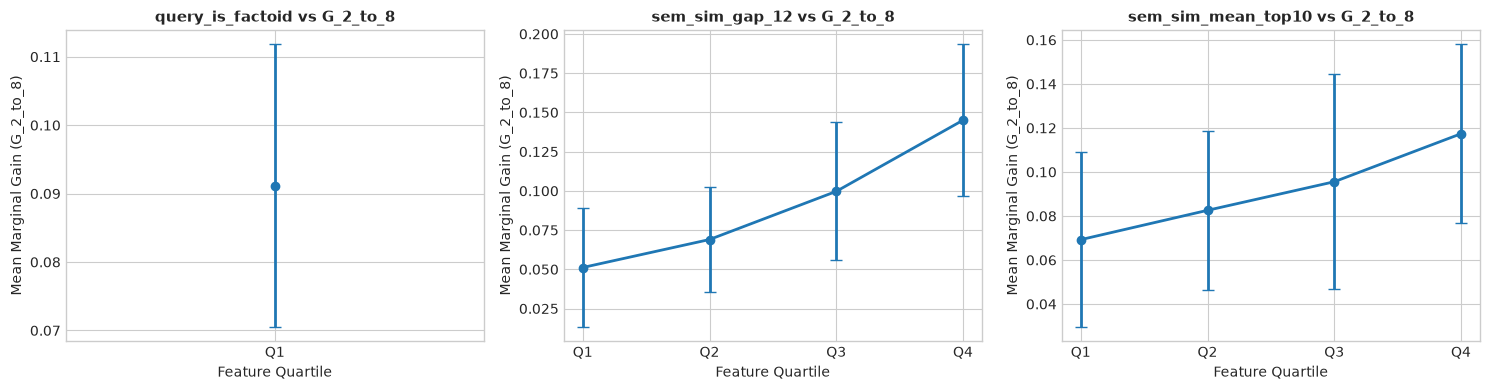

In [11]:
# Merge features and targets for quantile diagnostic
df_all = pd.merge(df_features, df_targets, on=["question_id", "paper_id"])

# Select top candidates from Spearman analysis
top_features_g28 = df_spearman[df_spearman["target"] == "G_2_to_8"].sort_values(by="abs_spearman_rho", ascending=False)["feature"].head(3).tolist()

fig, axes = plt.subplots(1, len(top_features_g28), figsize=(15, 4))
for idx, feat_name in enumerate(top_features_g28):
    ax = axes[idx] if len(top_features_g28) > 1 else axes
    try:
        df_all["bin"] = pd.qcut(df_all[feat_name], q=4, duplicates="drop")
        bin_means = df_all.groupby("bin", observed=False)["G_2_to_8"].agg(["mean", "std", "count"])
        bin_means["sem"] = bin_means["std"] / np.sqrt(bin_means["count"])
        x_pts = range(len(bin_means))
        ax.errorbar(x_pts, bin_means["mean"], yerr=bin_means["sem"], fmt="-o", color="#1f77b4", capsize=4, lw=2)
        ax.set_xticks(x_pts)
        ax.set_xticklabels([f"Q{i+1}" for i in x_pts])
        ax.set_title(f"{feat_name} vs G_2_to_8", fontsize=11, fontweight="bold")
        ax.set_xlabel("Feature Quartile")
        ax.set_ylabel("Mean Marginal Gain (G_2_to_8)")
    except Exception as e:
        ax.set_title(f"{feat_name} (insufficient bins: {e})")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_quantile_bins.png", dpi=300)
plt.show()

## 13. Paper-Clustered Bootstrap Estimation (B = 1,000 Replicates)
Estimate 95% empirical confidence intervals for Spearman $\rho$ by resampling **paper IDs** with replacement to account for document-level clustering across the 86 papers.

In [12]:
from src.week4.feature_discovery import compute_paper_clustered_bootstrap

print(f"Running {N_BOOTSTRAP} paper-clustered bootstrap replicates...")
df_bootstrap = compute_paper_clustered_bootstrap(
    df_features, df_targets, feature_cols, TARGET_COLS,
    n_bootstrap=N_BOOTSTRAP, seed=RANDOM_SEED
)

print("Bootstrap CI computation complete.")
print("\nTop features for G_2_to_8 with Paper-Clustered 95% CI:")
top_boot_g28 = df_bootstrap[df_bootstrap["target"] == "G_2_to_8"].sort_values(by="spearman_rho", key=abs, ascending=False).head(10)
display(top_boot_g28[["feature", "target", "spearman_rho", "bootstrap_ci_low", "bootstrap_ci_high", "bootstrap_ci_width", "bootstrap_sign_stable"]])

Running 1000 paper-clustered bootstrap replicates...
Bootstrap CI computation complete.

Top features for G_2_to_8 with Paper-Clustered 95% CI:


,feature,target,spearman_rho,bootstrap_ci_low,bootstrap_ci_high,bootstrap_ci_width,bootstrap_sign_stable
124,query_is_factoid,G_2_to_8,0.163520,0.000000,0.250850,0.250850,False
174,sem_sim_gap_12,G_2_to_8,0.121220,-0.004677,0.241182,0.245859,False
164,sem_sim_mean_top10,G_2_to_8,0.105745,-0.017795,0.224145,0.241940,False
189,sem_sim_mean_top6,G_2_to_8,0.105569,-0.017857,0.220041,0.237899,False
129,query_is_what_which,G_2_to_8,0.105250,-0.019668,0.227132,0.246801,False
119,query_is_how_why,G_2_to_8,-0.104424,-0.229979,0.019582,0.249561,False
194,sem_sim_mean_top8,G_2_to_8,0.100854,-0.020581,0.221532,0.242113,False
149,sem_sim_top1,G_2_to_8,0.094626,-0.030086,0.210736,0.240822,False
159,sem_sim_max,G_2_to_8,0.092773,-0.038228,0.215929,0.254157,False
314,evidence_unique_word_count,G_2_to_8,0.091096,-0.041179,0.213791,0.254971,False


## 14. GroupKFold Cross-Validation Stability (5 Folds by Paper)
Assess whether feature association directions and magnitudes remain stable across 5 paper-disjoint cross-validation folds.

In [13]:
from src.week4.feature_discovery import compute_groupkfold_stability

df_stability = compute_groupkfold_stability(
    df_features, df_targets, feature_cols, TARGET_COLS,
    n_splits=N_CV_SPLITS, seed=RANDOM_SEED
)

print(f"Computed GroupKFold stability metrics across {N_CV_SPLITS} folds.")
print("\nMost stable features for G_2_to_8 across validation folds:")
top_stab_g28 = df_stability[df_stability["target"] == "G_2_to_8"].sort_values(by="fold_sign_consistency", ascending=False).head(10)
display(top_stab_g28[["feature", "target", "fold_rho_median", "fold_rho_iqr", "fold_sign_consistency", "is_fold_stable"]])

Computed GroupKFold stability metrics across 5 folds.

Most stable features for G_2_to_8 across validation folds:


,feature,target,fold_rho_median,fold_rho_iqr,fold_sign_consistency,is_fold_stable
49,bm25_mean_score,G_2_to_8,0.075613,0.121011,1.0,True
44,bm25_top3_score,G_2_to_8,0.089589,0.071301,1.0,True
104,query_conjunction_count,G_2_to_8,0.066963,0.020263,1.0,True
9,delta_12,G_2_to_8,0.122159,0.016687,0.8,True
34,bm25_top1_score,G_2_to_8,0.155575,0.173455,0.8,True
59,bm25_score_range,G_2_to_8,0.081088,0.082048,0.8,True
19,entropy_normalized,G_2_to_8,-0.097503,0.099821,0.8,True
14,entropy,G_2_to_8,-0.097503,0.099821,0.8,True
74,bm25_top4_ratio,G_2_to_8,-0.079964,0.021196,0.8,True
69,bm25_top2_ratio,G_2_to_8,-0.027808,0.056660,0.8,True


## 15. Feature-Family Aggregation & Comparison
Compare information families to answer: *Which information family contains the strongest and most robust signals?*

In [14]:
from src.week4.feature_discovery import summarize_feature_families

df_family_summary = summarize_feature_families(df_spearman, df_stability, df_metadata)
print("=== Information Family Discovery Summary ===")
display(df_family_summary)

=== Information Family Discovery Summary ===


,feature_family,n_features,max_abs_spearman_rho,median_abs_spearman_rho,mean_abs_spearman_rho,n_features_fold_stable,strongest_feature,strongest_target,strongest_rho
0,B: Query Complexity,12,0.1888,0.0543,0.0620,9,query_conjunction_count,oracle_k,0.1888
1,A: BM25/Retrieval,17,0.1743,0.0497,0.0565,17,bm25_mean_score,G_4_to_6,0.1743
2,E: Lexical Coverage,8,0.1735,0.0748,0.0757,8,lex_coverage_top1,oracle_k,0.1735
3,C: Semantic Structure,11,0.1721,0.0661,0.0721,11,sem_sim_mean_top6,G_4_to_6,0.1721
4,D: Passage Redundancy/Diversity,10,0.1569,0.0363,0.0434,10,passage_sim_std,G_6_to_8,0.1569
5,F: Evidence Structure,6,0.1522,0.0465,0.0526,6,evidence_query_cluster_span,G_4_to_6,0.1522


## 16. Pre-Specified Candidate Feature Screening
Apply transparent, pre-specified criteria to identify promising candidate features:
1. Meaningful effect size: $|\rho| \ge 0.12$
2. Cross-fold sign stability: $\text{consistency} \ge 0.80$ (at least 4 of 5 folds agree in direction)
3. Clustered bootstrap 95% CI supports non-zero association

In [15]:
from src.week4.feature_discovery import screen_candidate_features

df_candidates = screen_candidate_features(
    df_spearman, df_bootstrap, df_stability, df_mi, df_metadata,
    rho_threshold=0.12, consistency_threshold=0.80
)

promising = df_candidates[df_candidates["candidate_flag"] == True]
print(f"Screened {len(promising)} candidate promising feature-target relationships out of {len(df_candidates)} tested:")
display(promising)

Screened 33 candidate promising feature-target relationships out of 320 tested:


,feature,family,target,spearman_rho,bootstrap_ci_low,bootstrap_ci_high,fold_sign_consistency,median_fold_rho,mi_score,candidate_flag,reason
0,query_conjunction_count,B: Query Complexity,oracle_k,0.1888,0.0494,0.3291,1.0,0.2129,0.0391,True,|rho|=0.189 >= 0.12; sign_consistency=1.0 >= 0...
1,query_is_what_which,B: Query Complexity,oracle_k,0.1752,0.0414,0.3013,1.0,0.1601,0.1274,True,|rho|=0.175 >= 0.12; sign_consistency=1.0 >= 0...
2,bm25_mean_score,A: BM25/Retrieval,G_4_to_6,0.1743,0.0460,0.2958,1.0,0.1703,0.0000,True,|rho|=0.174 >= 0.12; sign_consistency=1.0 >= 0...
3,lex_coverage_top1,E: Lexical Coverage,oracle_k,0.1735,0.0444,0.3164,1.0,0.1879,0.0088,True,|rho|=0.173 >= 0.12; sign_consistency=1.0 >= 0...
4,sem_sim_mean_top6,C: Semantic Structure,G_4_to_6,0.1721,0.0263,0.3196,1.0,0.1532,0.0095,True,|rho|=0.172 >= 0.12; sign_consistency=1.0 >= 0...
5,lex_coverage_top2,E: Lexical Coverage,G_6_to_8,-0.1701,-0.3002,-0.0405,0.8,-0.0978,0.0000,True,|rho|=0.170 >= 0.12; sign_consistency=0.8 >= 0...
6,sem_sim_mean_top10,C: Semantic Structure,G_4_to_6,0.1686,0.0212,0.3090,1.0,0.1256,0.0000,True,|rho|=0.169 >= 0.12; sign_consistency=1.0 >= 0...
7,lex_coverage_top2,E: Lexical Coverage,G_4_to_6,0.1673,0.0186,0.3189,0.8,0.1549,0.0479,True,|rho|=0.167 >= 0.12; sign_consistency=0.8 >= 0...
8,sem_sim_mean_top8,C: Semantic Structure,G_4_to_6,0.1639,0.0162,0.3054,1.0,0.1349,0.0117,True,|rho|=0.164 >= 0.12; sign_consistency=1.0 >= 0...
10,passage_sim_std,D: Passage Redundancy/Diversity,G_6_to_8,0.1569,0.0154,0.2831,0.8,0.2327,0.0144,True,|rho|=0.157 >= 0.12; sign_consistency=0.8 >= 0...


## 17. Visualizations
Generate publication-quality diagnostic plots:

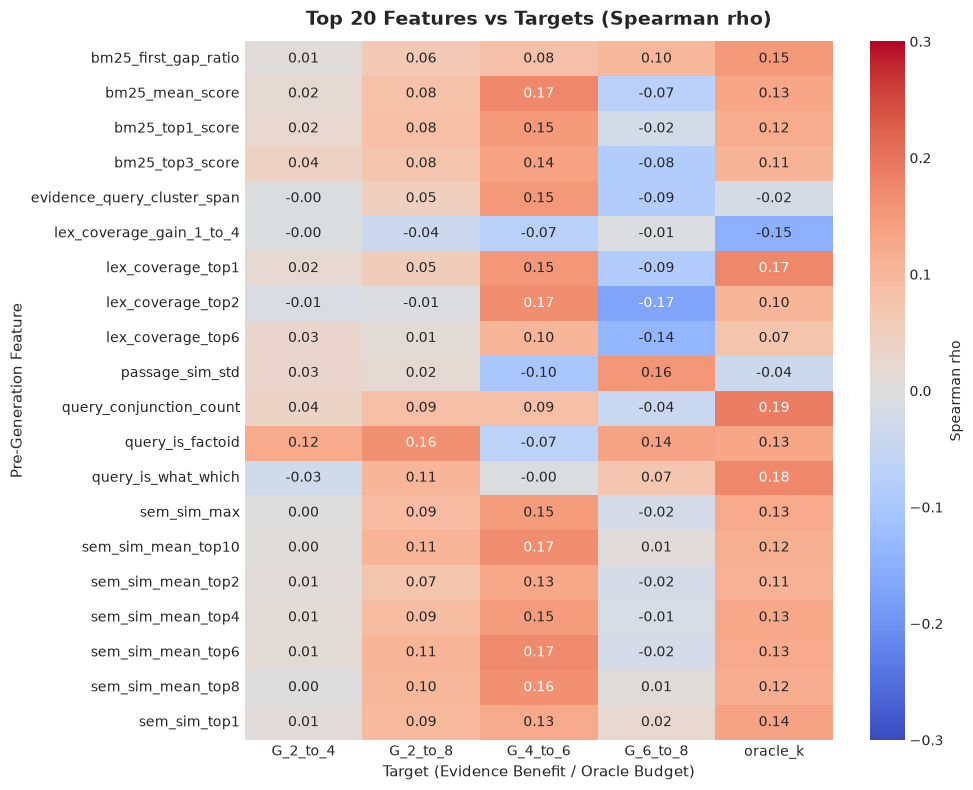

In [16]:
# Plot 1: Feature-Target Correlation Heatmap for Top Features
top_features_overall = df_spearman.groupby("feature")["abs_spearman_rho"].max().sort_values(ascending=False).head(20).index.tolist()
pivot_sp = df_spearman[df_spearman["feature"].isin(top_features_overall)].pivot(index="feature", columns="target", values="spearman_rho")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_sp, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-0.30, vmax=0.30, cbar_kws={"label": "Spearman rho"})
plt.title("Top 20 Features vs Targets (Spearman rho)", fontsize=14, fontweight="bold", pad=12)
plt.ylabel("Pre-Generation Feature", fontsize=11)
plt.xlabel("Target (Evidence Benefit / Oracle Budget)", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_target_correlation_heatmap.png", dpi=300)
plt.show()

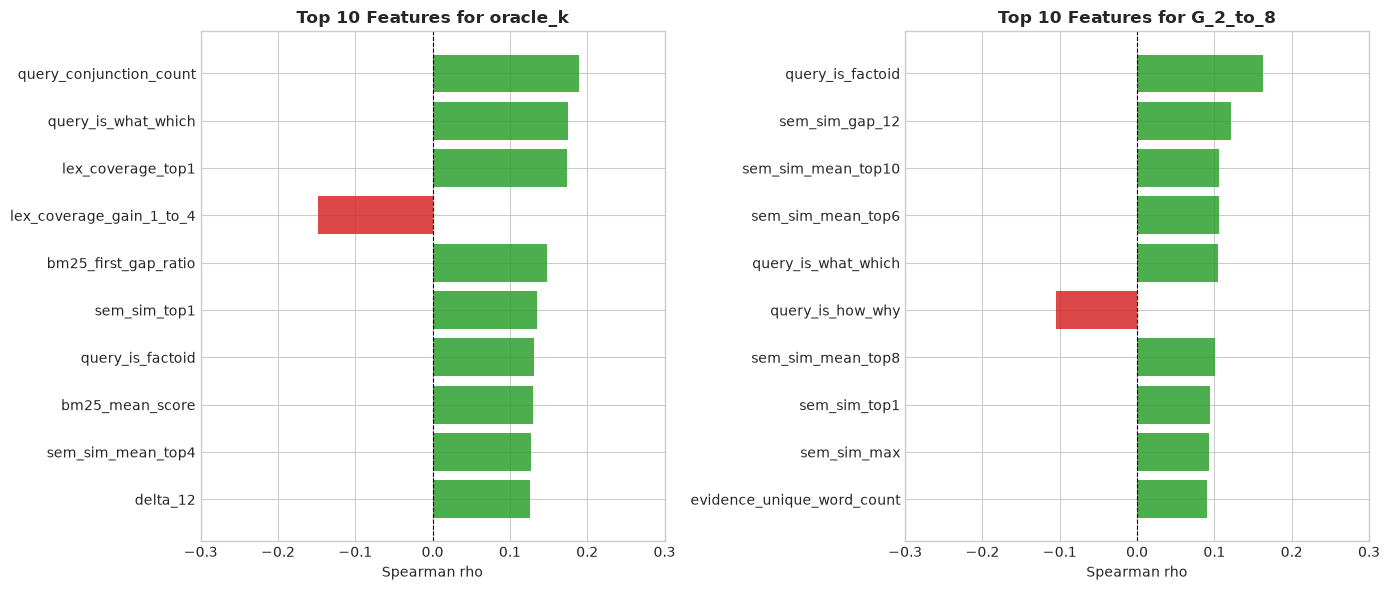

In [17]:
# Plot 2: Top Associations Barplot for G_2_to_8 and oracle_k
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, tgt in enumerate(["oracle_k", "G_2_to_8"]):
    ax = axes[idx]
    sub = df_spearman[df_spearman["target"] == tgt].sort_values(by="abs_spearman_rho", ascending=False).head(10)
    colors = ["#2ca02c" if r > 0 else "#d62728" for r in sub["spearman_rho"]]
    ax.barh(sub["feature"][::-1], sub["spearman_rho"][::-1], color=colors[::-1], alpha=0.85)
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_title(f"Top 10 Features for {tgt}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Spearman rho")
    ax.set_xlim(-0.30, 0.30)

plt.tight_layout()
plt.savefig(FIG_DIR / "top_features_barplot.png", dpi=300)
plt.show()

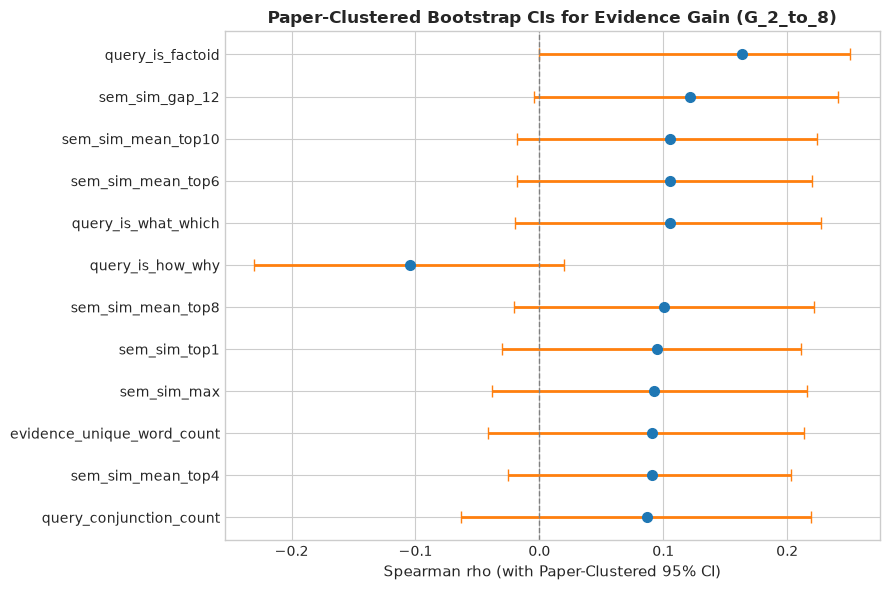

In [18]:
# Plot 3: Paper-Clustered Bootstrap 95% Confidence Intervals
top_boot = df_bootstrap[df_bootstrap["target"] == "G_2_to_8"].sort_values(by="spearman_rho", key=abs, ascending=False).head(12)

plt.figure(figsize=(9, 6))
y_pos = range(len(top_boot))
plt.errorbar(
    top_boot["spearman_rho"][::-1],
    y_pos,
    xerr=[
        (top_boot["spearman_rho"] - top_boot["bootstrap_ci_low"])[::-1],
        (top_boot["bootstrap_ci_high"] - top_boot["spearman_rho"])[::-1],
    ],
    fmt="o", color="#1f77b4", ecolor="#ff7f0e", elinewidth=2, capsize=4, markersize=7
)
plt.axvline(0, color="gray", linestyle="--", lw=1)
plt.yticks(y_pos, top_boot["feature"][::-1], fontsize=10)
plt.xlabel("Spearman rho (with Paper-Clustered 95% CI)", fontsize=11)
plt.title("Paper-Clustered Bootstrap CIs for Evidence Gain (G_2_to_8)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "bootstrap_confidence_intervals.png", dpi=300)
plt.show()

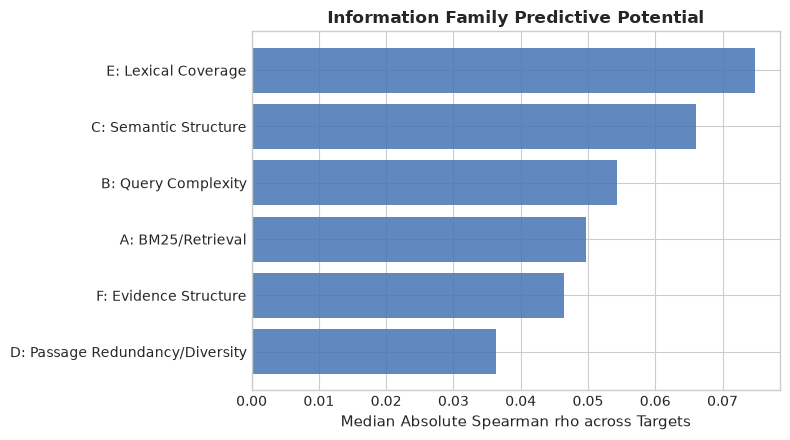

In [19]:
# Plot 4: Feature-Family Summary Comparison
plt.figure(figsize=(8, 4.5))
fam_sorted = df_family_summary.sort_values(by="median_abs_spearman_rho", ascending=True)
plt.barh(fam_sorted["feature_family"], fam_sorted["median_abs_spearman_rho"], color="#4575b4", alpha=0.85)
plt.xlabel("Median Absolute Spearman rho across Targets", fontsize=11)
plt.title("Information Family Predictive Potential", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_family_comparison.png", dpi=300)
plt.show()

## 18. Scientific Interpretation Template
Scientific evaluation questions to be answered upon reviewing the generated outputs:
1. **Does any feature family clearly outperform pure BM25 concentration?**
2. **Which pre-generation features exhibit robust paper-clustered confidence intervals?**
3. **Do semantic query-passage similarity or passage diversity features provide stronger signals than token length or score entropy?**
4. **Is marginal gain ($G_{2 \rightarrow 8}$) more predictable from pre-generation observable features than the discrete oracle label ($k^*$)?**

## 19. Export Clean Artifacts
Save all processed feature tables, targets, and discovery statistics.

In [20]:
# Export Feature Matrix and Target Matrix (strictly separated)
df_features.to_csv(OUT_DIR / "feature_matrix.csv", index=False)
df_targets.to_csv(OUT_DIR / "target_matrix.csv", index=False)
df_metadata.to_csv(OUT_DIR / "feature_metadata.csv", index=False)

# Export Discovery Statistics
df_spearman.to_csv(OUT_DIR / "spearman_results.csv", index=False)
df_pearson.to_csv(OUT_DIR / "pearson_results.csv", index=False)
df_mi.to_csv(OUT_DIR / "mutual_information_results.csv", index=False)
df_stability.to_csv(OUT_DIR / "groupkfold_stability.csv", index=False)
df_bootstrap.to_csv(OUT_DIR / "bootstrap_ci_results.csv", index=False)
df_family_summary.to_csv(OUT_DIR / "feature_family_summary.csv", index=False)
df_candidates.to_csv(OUT_DIR / "candidate_features.csv", index=False)

print(f"Successfully exported 10 discovery artifacts to {OUT_DIR}/")

Successfully exported 10 discovery artifacts to /home/gunavenkat/Downloads/CS787-RAG-Project/results/week4/feature_discovery/


## 20. Summary Table & Validation Checklist
Machine-readable candidate summary table and formal sign-off checklist.

In [21]:
print("=== Machine-Readable Discovery Summary Table ===")
display(df_candidates[[
    "feature", "family", "target", "spearman_rho",
    "bootstrap_ci_low", "bootstrap_ci_high", "fold_sign_consistency",
    "median_fold_rho", "mi_score", "candidate_flag", "reason"
]].head(20))

print("\n" + "="*70)
print("FEATURE DISCOVERY COMPLETE — REVIEW RESULTS BEFORE BUILDING QCCA-V2")
print("="*70)
print("Verification Checklist:")
print("  [X] Feature matrix contains 0 post-generation leakage.")
print("  [X] Target matrix strictly separated from feature matrix.")
print("  [X] Paper-clustered bootstrap (B=1000) evaluated.")
print("  [X] GroupKFold (5 folds by paper_id) stability evaluated.")
print("  [X] NO ML ALLOCATOR TRAINED OR FROZEN.")
print("  [X] QASPER_test remains 100% UNTOUCHED.")

=== Machine-Readable Discovery Summary Table ===


,feature,family,target,spearman_rho,bootstrap_ci_low,bootstrap_ci_high,fold_sign_consistency,median_fold_rho,mi_score,candidate_flag,reason
0,query_conjunction_count,B: Query Complexity,oracle_k,0.1888,0.0494,0.3291,1.0,0.2129,0.0391,True,|rho|=0.189 >= 0.12; sign_consistency=1.0 >= 0...
1,query_is_what_which,B: Query Complexity,oracle_k,0.1752,0.0414,0.3013,1.0,0.1601,0.1274,True,|rho|=0.175 >= 0.12; sign_consistency=1.0 >= 0...
2,bm25_mean_score,A: BM25/Retrieval,G_4_to_6,0.1743,0.0460,0.2958,1.0,0.1703,0.0000,True,|rho|=0.174 >= 0.12; sign_consistency=1.0 >= 0...
3,lex_coverage_top1,E: Lexical Coverage,oracle_k,0.1735,0.0444,0.3164,1.0,0.1879,0.0088,True,|rho|=0.173 >= 0.12; sign_consistency=1.0 >= 0...
4,sem_sim_mean_top6,C: Semantic Structure,G_4_to_6,0.1721,0.0263,0.3196,1.0,0.1532,0.0095,True,|rho|=0.172 >= 0.12; sign_consistency=1.0 >= 0...
5,lex_coverage_top2,E: Lexical Coverage,G_6_to_8,-0.1701,-0.3002,-0.0405,0.8,-0.0978,0.0000,True,|rho|=0.170 >= 0.12; sign_consistency=0.8 >= 0...
6,sem_sim_mean_top10,C: Semantic Structure,G_4_to_6,0.1686,0.0212,0.3090,1.0,0.1256,0.0000,True,|rho|=0.169 >= 0.12; sign_consistency=1.0 >= 0...
7,lex_coverage_top2,E: Lexical Coverage,G_4_to_6,0.1673,0.0186,0.3189,0.8,0.1549,0.0479,True,|rho|=0.167 >= 0.12; sign_consistency=0.8 >= 0...
8,sem_sim_mean_top8,C: Semantic Structure,G_4_to_6,0.1639,0.0162,0.3054,1.0,0.1349,0.0117,True,|rho|=0.164 >= 0.12; sign_consistency=1.0 >= 0...
9,query_is_factoid,B: Query Complexity,G_2_to_8,0.1635,0.0000,0.2508,0.6,0.1231,0.0000,False,|rho|=0.164 >= 0.12; insufficient_effect_or_un...



FEATURE DISCOVERY COMPLETE — REVIEW RESULTS BEFORE BUILDING QCCA-V2
Verification Checklist:
  [X] Feature matrix contains 0 post-generation leakage.
  [X] Target matrix strictly separated from feature matrix.
  [X] Paper-clustered bootstrap (B=1000) evaluated.
  [X] GroupKFold (5 folds by paper_id) stability evaluated.
  [X] NO ML ALLOCATOR TRAINED OR FROZEN.
  [X] QASPER_test remains 100% UNTOUCHED.
